# Freight Rate Prediction - EDA
## 1. Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

train = pd.read_csv("../data/train_test.csv", parse_dates=["date"])
val = pd.read_csv("../data/validation.csv", parse_dates=["date"])
dec = pd.read_csv("../data/december_chart_inputs.csv", parse_dates=["date"])

print("train:", train.shape)
print("val:  ", val.shape)
print("dec:  ", dec.shape)

train: (48000, 14)
val:   (12000, 13)
dec:   (31, 7)


In [2]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
train.dtypes

load_id                 object
pickup                  object
delivery                object
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment               object
weight                 float64
date            datetime64[ns]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object

In [4]:
print("In train but not val:", set(train.columns) - set(val.columns))
print("In train but not dec:", set(train.columns) - set(dec.columns))

In train but not val: {'posted_rate'}
In train but not dec: {'delivery_lon', 'quote_signal', 'posted_rate', 'delivery_lat', 'pickup_lat', 'load_id', 'pickup_lon', 'market_index'}


In [5]:
for name, df in [("train", train), ("val", val), ("dec", dec)]:
    print(f"{name:6s} {df['date'].min().date()} -> {df['date'].max().date()} "
          f"({df['date'].nunique()} days)")

train  2025-01-01 -> 2025-10-31 (304 days)
val    2025-11-01 -> 2025-12-31 (61 days)
dec    2025-12-01 -> 2025-12-31 (31 days)


In [6]:
train.nunique()

load_id         48000
pickup             64
delivery           64
pickup_lat         64
pickup_lon         63
delivery_lat       64
delivery_lon       63
distance        21204
equipment           3
weight          23678
date              304
market_index    32884
quote_signal    37633
posted_rate     45398
dtype: int64

### Observations: overview
- Train covers Jan–Oct 2025, validation covers Nov–Dec 2025 -> this is a forecasting problem, so a random split would leak future information. I'll use a time-based split.
- December chart inputs fall inside the validation period, but lack market_index, quote_signal and coordinates -> need a strategy to fill them if the model uses them.
- 64 cities but only 63 unique longitudes -> two cities share the exact same longitude. Suspicious, to investigate.
- market_index has ~33k unique values across 304 days -> it varies per load, not just per day.
- No missing days in the training period.

## 2. Target: posted_rate

In [7]:
train["posted_rate"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(2)

count    48000.00
mean      2373.98
std       1486.49
min         57.22
1%         327.17
5%         599.74
50%       2030.76
95%       4953.77
99%       5972.83
max      25533.00
Name: posted_rate, dtype: float64

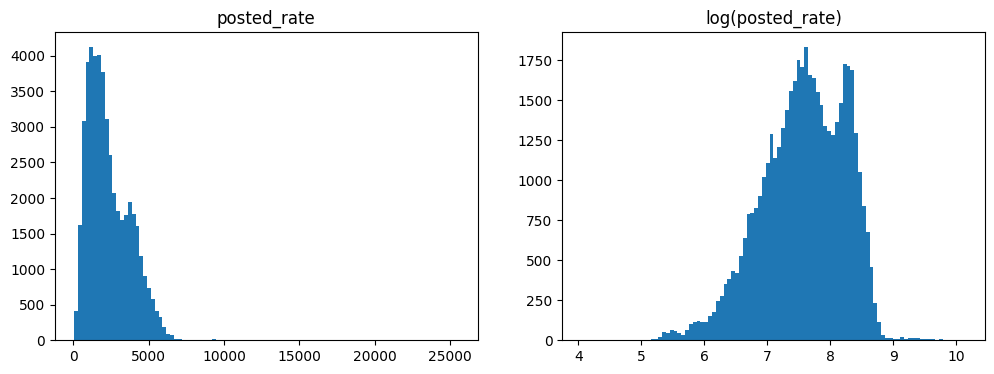

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train["posted_rate"], bins=100)
axes[0].set_title("posted_rate")
axes[1].hist(np.log(train["posted_rate"]), bins=100)
axes[1].set_title("log(posted_rate)")
plt.show()

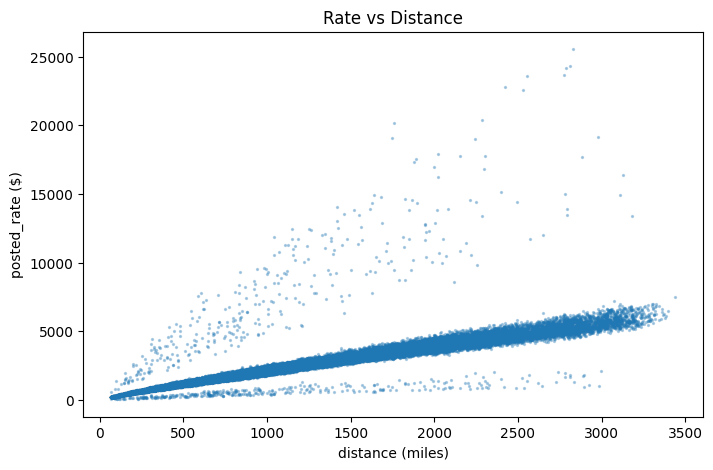

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(train["distance"], train["posted_rate"], s=2, alpha=0.3)
plt.xlabel("distance (miles)")
plt.ylabel("posted_rate ($)")
plt.title("Rate vs Distance")
plt.show()

In [10]:
train["rpm"] = train["posted_rate"] / train["distance"]
train["rpm"].describe(percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]).round(3)

count    48000.000
mean         2.215
std          0.584
min          0.334
0.1%         0.437
1%           1.674
5%           1.808
50%          2.145
95%          2.736
99%          3.177
99.9%       10.069
max         14.125
Name: rpm, dtype: float64

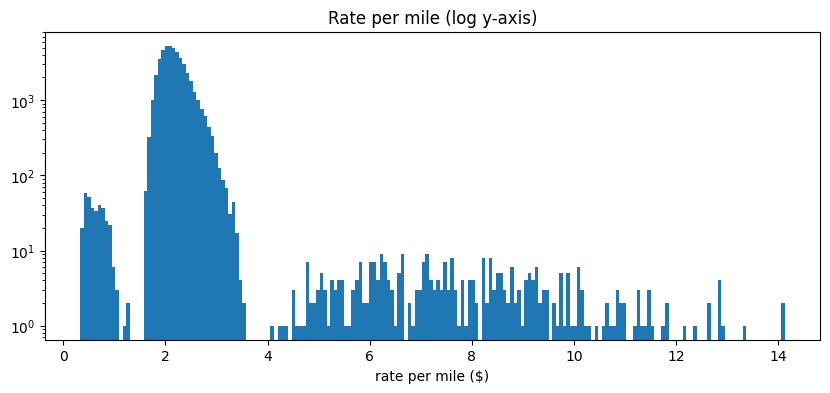

In [11]:
plt.figure(figsize=(10, 4))
plt.hist(train["rpm"], bins=200)
plt.yscale("log")
plt.xlabel("rate per mile ($)")
plt.title("Rate per mile (log y-axis)")
plt.show()

### Observations: target
- Rate grows roughly linearly with distance - distance is clearly the dominant driver.
- Rate per mile shows three separated clusters: ~0.3–1.2, ~1.6–3.6 (bulk), and ~4–14 $/mile, with empty gaps between them.
- The gaps suggest these are not genuine market extremes but likely data-entry / scaling errors in the label.
- Roughly 1–2% of rows are affected. Need to quantify and check if they follow any pattern before deciding how to handle them.

In [12]:
train["rpm_group"] = pd.cut(train["rpm"], bins=[0, 1.4, 3.8, np.inf],
                            labels=["low", "normal", "high"])
train["rpm_group"].value_counts()

rpm_group
normal    47323
high        340
low         337
Name: count, dtype: int64

In [13]:
pd.crosstab(train["equipment"], train["rpm_group"], normalize="index").round(4)

rpm_group,low,normal,high
equipment,,,
Dry Van,0.0063,0.9865,0.0072
Flatbed,0.0073,0.9855,0.0072
Reefer,0.0085,0.9849,0.0066


In [14]:
pd.crosstab(train["date"].dt.month, train["rpm_group"], normalize="index").round(4)

rpm_group,low,normal,high
date,,,
1,0.0081,0.9835,0.0083
2,0.0065,0.9869,0.0067
3,0.0073,0.9859,0.0068
4,0.0075,0.9863,0.0062
5,0.0075,0.9874,0.0051
6,0.0050,0.9868,0.0082
7,0.0059,0.9868,0.0073
8,0.0074,0.9857,0.0069
9,0.0064,0.9863,0.0073


In [15]:
lane_median = train.groupby(["pickup", "delivery"])["rpm"].transform("median")
train["ratio_to_lane"] = train["rpm"] / lane_median
train.groupby("rpm_group", observed=True)["ratio_to_lane"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
rpm_group,,,,,,,,
low,337.0,0.30,0.09,0.17,0.22,0.29,0.36,1.00
normal,47323.0,1.01,0.07,0.28,0.96,1.00,1.05,1.63
high,340.0,3.50,0.87,1.36,2.82,3.37,4.25,6.10


### Observations: label outliers
- ~677 rows (1.4%) fall outside the normal rate-per-mile range.
- Their share is flat (~0.7% each side) across all equipment types and all months -> no seasonal or equipment pattern -> consistent with random label corruption, not real market behaviour.
- Relative to their own lane's median, low outliers sit at ~0.3x and high outliers at ~3.5x, with a variable factor -> not a single fixed scaling error.
- Next: check whether a lane-relative rule detects them better than a global rpm threshold.

In [16]:
train["is_outlier"] = (train["ratio_to_lane"] > 2) | (train["ratio_to_lane"] < 0.6)
print("Outliers (lane rule):", train["is_outlier"].sum())
pd.crosstab(train["rpm_group"], train["is_outlier"])

Outliers (lane rule): 674


is_outlier,False,True
rpm_group,,
low,1,336
normal,47321,2
high,4,336


In [17]:
lane_size = train.groupby(["pickup", "delivery"])["rpm"].transform("size")
train["lane_size"] = lane_size

disagree = train[(train["rpm_group"] != "normal") != train["is_outlier"]]
disagree[["pickup", "delivery", "distance", "equipment", "posted_rate",
          "rpm", "ratio_to_lane", "lane_size", "rpm_group"]]

,pickup,delivery,distance,equipment,posted_rate,rpm,ratio_to_lane,lane_size,rpm_group
2803,Oklahoma City,Birmingham,824.1,Dry Van,3930.74,4.769737,1.936907,9,high
9694,Boston,Louisville,1206.3,Dry Van,5417.50,4.491006,1.364320,2,high
12003,Dallas,Grand Rapids,1068.3,Dry Van,1991.36,1.864046,0.280571,2,normal
17889,Savannah,Detroit,803.2,Dry Van,1745.20,2.172809,0.591955,2,normal
22730,Dallas,Grand Rapids,1041.3,Reefer,11895.25,11.423461,1.719429,2,high
26574,Tampa,Detroit,1253.0,Reefer,605.83,0.483504,1.000000,1,low
29789,Savannah,Detroit,842.0,Dry Van,4351.72,5.168314,1.408045,2,high


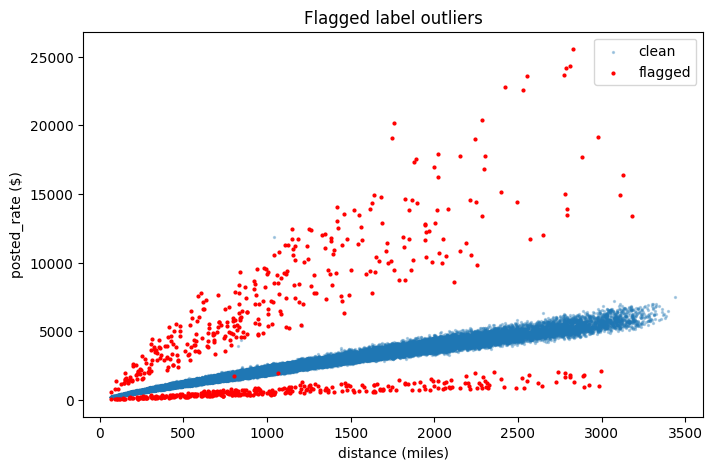

In [18]:
plt.figure(figsize=(8, 5))
clean = train[~train["is_outlier"]]
bad = train[train["is_outlier"]]
plt.scatter(clean["distance"], clean["posted_rate"], s=2, alpha=0.3, label="clean")
plt.scatter(bad["distance"], bad["posted_rate"], s=4, color="red", label="flagged")
plt.xlabel("distance (miles)")
plt.ylabel("posted_rate ($)")
plt.legend()
plt.title("Flagged label outliers")
plt.show()

### Observations: choosing the outlier rule
- Tested a lane-relative rule (ratio to lane median) against the global rpm threshold. They agree on 670 rows and disagree on 7.
- All 7 disagreements are in lanes with only 1–9 loads (mostly 2). With so few loads, the lane median is itself contaminated by the outlier (e.g. a lane with one good and one corrupted load), so the lane rule flags the clean load and misses the bad one.
- The global threshold (rpm < 1.4 or > 3.8) is correct in all 7 cases. It works because the rpm histogram has clean empty gaps around the normal range, so the cut-off sits inside a gap.
- Decision: use the global rpm threshold -> 677 rows (1.4%) flagged as label corruption and excluded from training.

In [19]:
# Final decision: global rpm threshold
train["is_outlier"] = train["rpm_group"] != "normal"
print("Flagged:", train["is_outlier"].sum())

Flagged: 677


## 3. Features
### 3.1 Weight

In [20]:
train["weight"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(1)

count    47700.0
mean     31028.8
std       9391.4
min     -47500.0
1%        9802.0
5%       17491.0
50%      31436.5
95%      44934.2
99%      47500.0
max      47500.0
Name: weight, dtype: float64

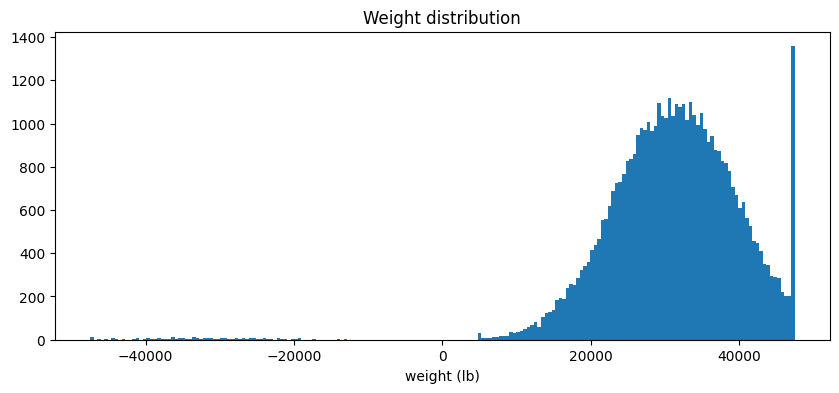

In [21]:
plt.figure(figsize=(10, 4))
plt.hist(train["weight"].dropna(), bins=200)
plt.xlabel("weight (lb)")
plt.title("Weight distribution")
plt.show()

In [22]:
train["weight"].value_counts().head(10)

weight
 47500.0    1191
 5000.0       31
-47500.0      13
 32436.0      10
 32153.0      10
 28444.0       9
 26564.0       9
 28876.0       9
 34863.0       9
 31460.0       9
Name: count, dtype: int64

In [23]:
w = train[~train["is_outlier"] & (train["weight"] > 0)]
w.groupby(pd.cut(w["weight"], bins=10), observed=True)["rpm"].median().round(3)

weight
(4957.5, 9250.0]      2.023
(9250.0, 13500.0]     2.062
(13500.0, 17750.0]    2.057
(17750.0, 22000.0]    2.068
(22000.0, 26250.0]    2.087
(26250.0, 30500.0]    2.120
(30500.0, 34750.0]    2.159
(34750.0, 39000.0]    2.193
(39000.0, 43250.0]    2.215
(43250.0, 47500.0]    2.210
Name: rpm, dtype: float64

In [24]:
clean = train[~train["is_outlier"]].copy()
clean["abs_weight"] = clean["weight"].abs()
clean["sign"] = np.where(clean["weight"] < 0, "negative", "positive")

bins = [0, 20000, 30000, 40000, 50000]
clean.groupby([pd.cut(clean["abs_weight"], bins), "sign"], observed=True)["rpm"] \
     .agg(["median", "count"]).round(3).unstack()

median             count         
sign           negative positive negative positive
abs_weight                                        
(0, 20000]        1.964    2.059       23     3693
(20000, 30000]    2.185    2.100       94    16332
(30000, 40000]    2.172    2.175      123    19752
(40000, 50000]    2.160    2.212       43     6966

### Observations: weight
- 292 negative weights (range ≈ -47,500 to -13,000) mirror the positive distribution, including 13 rows at exactly -47,500 (the same value as the upper cap) -> most likely a sign error applied after capping.
- Rate-per-mile of negative-weight loads is close to that of positive loads in the same |weight| bin (e.g. 2.172 vs 2.175 in the 30–40k bin). This is consistent with a sign flip, but the test is weak: weight has only a modest effect on price and the negative groups are small.
- Decision: take abs(weight). Impact is limited either way.
- Spike of 1,191 rows at exactly 47,500 -> values are capped at an upper limit. The true weight above the cap is unrecoverable; kept as-is.
- Small spike at exactly 5,000 (31 rows) and no positive weights below it -> lower floor cap.
- Weight has a real but modest monotonic effect: median rpm rises from ~2.02 (lightest) to ~2.21 (heaviest), flattening above ~39k lb.
- 300 missing values in train -> handled in the missing-values section.

### 3.2 Distance & coordinates

In [25]:
print(train["distance"].describe().round(1))
print("\nMost common distances:")
print(train["distance"].value_counts().head(5))

count    48000.0
mean      1135.9
std        728.6
min         70.0
25%        550.4
50%        953.3
75%       1645.5
max       3439.8
Name: distance, dtype: float64

Most common distances:
distance
70.0     48
446.3    12
741.1    11
758.9    11
429.3    10
Name: count, dtype: int64


In [26]:
cities = pd.concat([
    train[["pickup", "pickup_lat", "pickup_lon"]].set_axis(["city", "lat", "lon"], axis=1),
    train[["delivery", "delivery_lat", "delivery_lon"]].set_axis(["city", "lat", "lon"], axis=1),
]).drop_duplicates()

print("Coords per city:", cities.groupby("city").size().max())
print("\nShared longitudes:")
print(cities[cities["lon"].duplicated(keep=False)])
print("\nBounding box:")
print(cities[["lat", "lon"]].describe().loc[["min", "max"]])

Coords per city: 1

Shared longitudes:
          city       lat   lon
31  Providence  37.37287 -69.5
87      Boston  39.27463 -69.5

Bounding box:
          lat        lon
min  28.35765 -121.69849
max  44.30296  -69.50000


In [27]:
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2)**2
    return 3958.8 * 2 * np.arcsin(np.sqrt(a))

train["straight_line"] = haversine(train["pickup_lat"], train["pickup_lon"],
                                   train["delivery_lat"], train["delivery_lon"])
train["road_ratio"] = train["distance"] / train["straight_line"]
train["road_ratio"].describe(percentiles=[0.01, 0.5, 0.99]).round(2)

count    48000.00
mean         1.19
std          0.14
min          1.06
1%           1.13
50%          1.18
99%          1.40
max          9.63
Name: road_ratio, dtype: float64

In [28]:
d70 = train[train["distance"] == 70]
d70.groupby(["pickup", "delivery"]).agg(
    n=("distance", "size"),
    straight_line=("straight_line", "first"),
    median_rpm=("rpm", "median"),
).round(2)

n  straight_line  median_rpm
pickup       delivery                                  
Austin       Lubbock       4          34.46        3.22
Chattanooga  Atlanta       1          59.45        3.02
             Nashville     2          50.90        3.38
Cincinnati   Louisville    3          40.93        2.97
Hartford     Philadelphia  8          47.80        3.00
Los Angeles  Phoenix       2          51.73        2.93
Louisville   Cincinnati    3          40.93        3.01
Lubbock      Austin        5          34.46        3.36
New Orleans  Shreveport    5           7.27        3.00
Philadelphia Hartford      5          47.80        2.98
Phoenix      Los Angeles   3          51.73        2.91
Shreveport   New Orleans   7           7.27        3.13

In [29]:
lanes70 = d70[["pickup", "delivery"]].drop_duplicates()
same_lanes = train.merge(lanes70, on=["pickup", "delivery"])
same_lanes.groupby(["pickup", "delivery"])["distance"].agg(["min", "median", "max", "count"])

min  median    max  count
pickup       delivery                                
Austin       Lubbock       70.0   70.00   78.9      5
Chattanooga  Atlanta       70.0   85.40  109.6     25
             Nashville     70.0   81.20   93.5     14
Cincinnati   Louisville    70.0   71.65   75.9      6
Hartford     Philadelphia  70.0   72.80   85.8     29
Los Angeles  Phoenix       70.0   78.50   93.9     29
Louisville   Cincinnati    70.0   72.10   81.6      7
Lubbock      Austin        70.0   70.00   70.0      5
New Orleans  Shreveport    70.0   70.00   70.0      5
Philadelphia Hartford      70.0   74.70   89.7     25
Phoenix      Los Angeles   70.0   77.40   95.4     21
Shreveport   New Orleans   70.0   70.00   70.0      7

In [30]:
train[train["road_ratio"] > 1.5][["pickup", "delivery", "distance",
                                  "straight_line", "road_ratio"]] \
    .drop_duplicates(["pickup", "delivery"]).sort_values("road_ratio", ascending=False)

,pickup,delivery,distance,straight_line,road_ratio
4140,New Orleans,Shreveport,70.0,7.265240,9.634919
9348,Shreveport,New Orleans,70.0,7.265240,9.634919
1464,Lubbock,Austin,70.0,34.462830,2.031174
8589,Austin,Lubbock,70.0,34.462830,2.031174
7765,Chattanooga,Atlanta,108.8,59.448369,1.830160
6510,Hartford,Philadelphia,85.8,47.797062,1.795089
5363,Atlanta,Chattanooga,103.1,59.448369,1.734278
2158,Chattanooga,Nashville,88.1,50.902706,1.730753
2115,Nashville,Chattanooga,87.7,50.902706,1.722895
5209,Cincinnati,Louisville,70.0,40.930400,1.710220


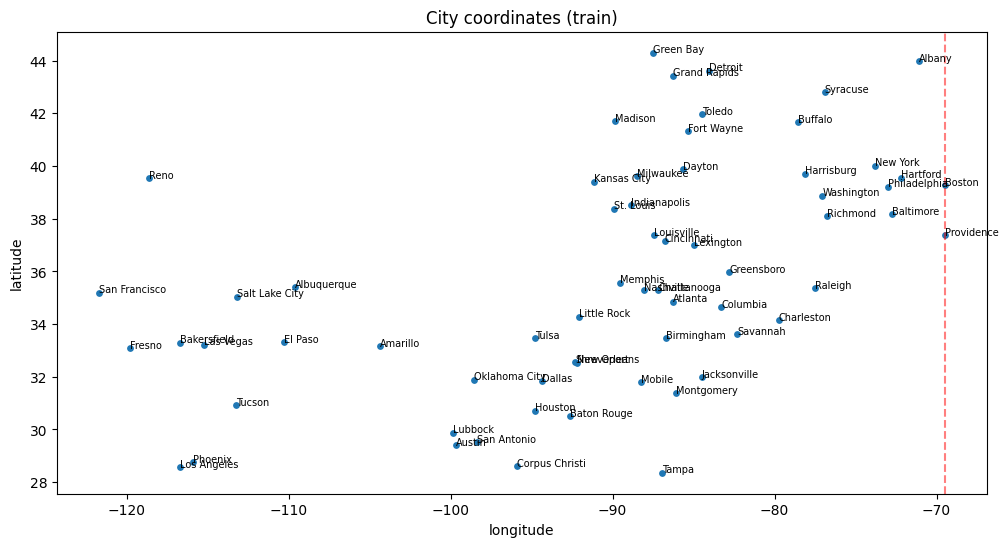

In [31]:
plt.figure(figsize=(12, 6))
plt.scatter(cities["lon"], cities["lat"], s=15)
for _, r in cities.iterrows():
    plt.annotate(r["city"], (r["lon"], r["lat"]), fontsize=7)
plt.axvline(-69.5, color="red", linestyle="--", alpha=0.5)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title("City coordinates (train)")
plt.show()

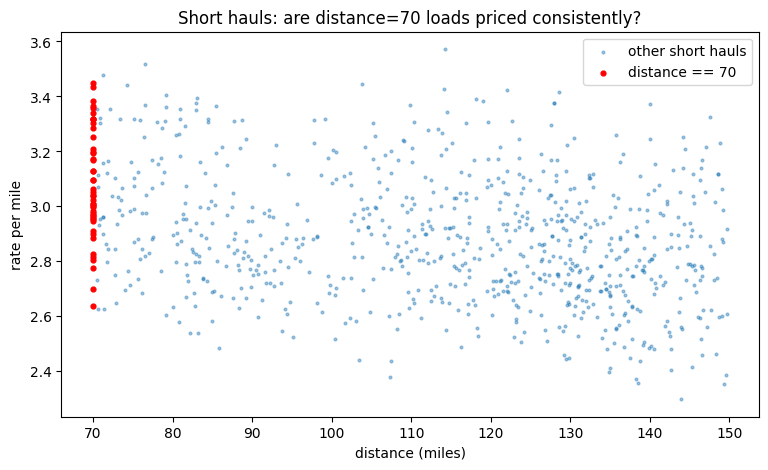

In [32]:
short = train[~train["is_outlier"] & (train["distance"] < 150)].copy()
short["is_70"] = short["distance"] == 70

plt.figure(figsize=(9, 5))
plt.scatter(short.loc[~short["is_70"], "distance"], short.loc[~short["is_70"], "rpm"],
            s=4, alpha=0.4, label="other short hauls")
plt.scatter(short.loc[short["is_70"], "distance"], short.loc[short["is_70"], "rpm"],
            s=12, color="red", label="distance == 70")
plt.xlabel("distance (miles)")
plt.ylabel("rate per mile")
plt.legend()
plt.title("Short hauls: are distance=70 loads priced consistently?")
plt.show()

### Observations: distance & coordinates
- 48 loads have distance of exactly 70.0, by far the most frequent value. All are on short lanes where other loads range 70–110 miles -> distance has a lower floor at 70.
- Rate-per-mile of these loads sits inside the range of nearby short hauls (70–80 mi) -> prices are consistent with the floored distance. Decision: keep distance as-is.
- Rate per mile decreases with distance (≈3.0 at 70 mi -> ≈2.8 at 150 mi), consistent with fixed per-load costs -> the rate–distance relationship is not perfectly linear.
- Each city has exactly one coordinate pair, and the map has a roughly US-like layout, but coordinates are clearly perturbed: e.g. New Orleans and Shreveport are 7 miles apart, Los Angeles and Phoenix 52 miles apart. Coordinates are approximate, not real geography.
- distance/straight-line ratio is ≈1.18 with low spread -> distance was derived from these same (perturbed) coordinates. Within this dataset, distance and coordinates are internally consistent; distance is the reliable feature.
- Boston and Providence both sit at exactly lon = -69.5, the eastern edge of the bounding box -> longitudes are clipped at -69.5.

### 3.3 Equipment

In [33]:
c = train[~train["is_outlier"]]
c.groupby("equipment")["rpm"].agg(["count", "median", "mean", "std"]).round(3)

,count,median,mean,std
equipment,,,,
Dry Van,26834,2.046,2.087,0.234
Flatbed,8626,2.220,2.263,0.257
Reefer,11863,2.312,2.357,0.264


In [34]:
dist_bins = pd.cut(c["distance"], bins=[0, 300, 700, 1200, 2000, 3500])
c.groupby([dist_bins, "equipment"], observed=True)["rpm"].median().unstack().round(3)

equipment,Dry Van,Flatbed,Reefer
distance,,,
"(0, 300]",2.566,2.776,2.894
"(300, 700]",2.231,2.420,2.520
"(700, 1200]",2.051,2.219,2.320
"(1200, 2000]",1.948,2.107,2.196
"(2000, 3500]",1.841,1.991,2.075


### Observations: equipment
- Dry Van is cheapest. Relative to Dry Van, Flatbed is ≈1.08x and Reefer ≈1.13x per mile.
- These ratios are almost identical in every distance band (Reefer/Dry Van ≈ 1.127–1.131) -> equipment has a multiplicative effect on price.
- Modelling log(rate) turns multiplicative effects into additive ones, which is a strong argument for a log-transformed target.
- Rate per mile decreases with distance for all three equipment types.

### 3.4 Cities & lanes

In [35]:
lanes = c.groupby(["pickup", "delivery"]).size()
print("Unique lanes:", len(lanes))
print("Possible lanes (64 x 63):", 64 * 63)
print(lanes.describe().round(1))

Unique lanes: 4013
Possible lanes (64 x 63): 4032
count    4013.0
mean       11.8
std         7.1
min         1.0
25%         6.0
50%        10.0
75%        16.0
max        39.0
dtype: float64


In [36]:
train_cities = set(train["pickup"]) | set(train["delivery"])
val_cities = set(val["pickup"]) | set(val["delivery"])
new_cities = sorted(val_cities - train_cities)
print("New cities:", new_cities)

touches_new = val["pickup"].isin(new_cities) | val["delivery"].isin(new_cities)
print(f"Validation rows touching a new city: {touches_new.sum()} ({touches_new.mean():.1%})")

val_lanes = set(zip(val["pickup"], val["delivery"]))
train_lanes = set(zip(train["pickup"], train["delivery"]))
unseen = [(p, d) in train_lanes for p, d in zip(val["pickup"], val["delivery"])]
print(f"Validation rows on a lane never seen in train: {(~np.array(unseen)).sum()}")

New cities: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']
Validation rows touching a new city: 1447 (12.1%)
Validation rows on a lane never seen in train: 1461


In [37]:
pick = c.groupby("pickup")["rpm"].median()
drop = c.groupby("delivery")["rpm"].median()
city_effect = pd.DataFrame({"as_pickup": pick, "as_delivery": drop})
city_effect["diff"] = city_effect["as_pickup"] - city_effect["as_delivery"]
city_effect.sort_values("diff").round(3).iloc[[0, 1, 2, 3, 4, -5, -4, -3, -2, -1]]

,as_pickup,as_delivery,diff
Montgomery,2.193,2.241,-0.048
Birmingham,2.241,2.279,-0.039
Austin,2.141,2.173,-0.031
Charleston,2.159,2.187,-0.028
Baltimore,2.082,2.110,-0.028
Little Rock,2.255,2.229,0.026
Harrisburg,2.146,2.118,0.028
Tampa,2.176,2.147,0.029
Chattanooga,2.291,2.235,0.055
Dallas,2.257,2.201,0.056


### Observations: cities & lanes
- 4,013 of 4,032 possible directed lanes appear in train (~12 loads per lane) -> almost every city pair exists, which suggests synthetic data rather than a real lane network.
- Validation contains 8 cities never seen in train (Allentown, Charlotte, Chicago, Jackson, Knoxville, Laredo, Norfolk, San Diego), touching 1,447 rows (12.1%).
- 1,461 validation rows are on unseen lanes -> nearly all of them are explained by the new cities.
- Implication: the model cannot rely on city / lane identity alone. It must generalise through distance and coordinates, which are the only location information available for new cities.
- Direction effect (city as pickup vs as delivery) is at most ≈±0.05 $/mile (<2.5%) and confounded by distance mix -> weak. To be verified on the holdout by comparing models with and without city features.

## 4. Missing values

In [38]:
missing = pd.DataFrame({
    "train_n": train.isna().sum(),
    "train_%": (train.isna().mean() * 100).round(2),
    "val_n": val.isna().sum(),
    "val_%": (val.isna().mean() * 100).round(2),
})
missing[(missing["train_n"] > 0) | (missing["val_n"] > 0)]

,train_n,train_%,val_n,val_%
market_index,374,0.78,249.0,2.08
weight,300,0.62,165.0,1.38


In [39]:
both = (train["weight"].isna() & train["market_index"].isna()).sum()
print("Rows missing both weight and market_index:", both)

Rows missing both weight and market_index: 1


In [40]:
for col in ["weight", "market_index"]:
    print(f"\n--- {col} missing rate (%) ---")
    print((train.groupby(train["date"].dt.month)[col].apply(lambda s: s.isna().mean()) * 100).round(2).to_dict())
    print((train.groupby("equipment")[col].apply(lambda s: s.isna().mean()) * 100).round(2).to_dict())


--- weight missing rate (%) ---
{1: 0.69, 2: 0.76, 3: 0.71, 4: 0.42, 5: 0.45, 6: 0.67, 7: 0.59, 8: 0.61, 9: 0.71, 10: 0.66}
{'Dry Van': 0.64, 'Flatbed': 0.63, 'Reefer': 0.58}

--- market_index missing rate (%) ---
{1: 0.73, 2: 0.83, 3: 0.87, 4: 0.64, 5: 0.88, 6: 0.88, 7: 0.73, 8: 0.69, 9: 0.66, 10: 0.87}
{'Dry Van': 0.74, 'Flatbed': 0.83, 'Reefer': 0.82}


In [41]:
for col in ["weight", "market_index"]:
    is_na = c[col].isna()
    print(f"{col}: rpm median when missing = {c.loc[is_na, 'rpm'].median():.3f}, "
          f"when present = {c.loc[~is_na, 'rpm'].median():.3f}")

weight: rpm median when missing = 2.122, when present = 2.146
market_index: rpm median when missing = 2.125, when present = 2.145


In [42]:
daily_mean = train.groupby("date")["market_index"].transform("mean")
within_day = (train["market_index"] - daily_mean).std()
across_days = train.groupby("date")["market_index"].mean().std()
print(f"Std within a day:  {within_day:.4f}")
print(f"Std across days:   {across_days:.4f}")

Std within a day:  0.0249
Std across days:   0.1665


### Observations: missing values
- Only two columns have missing values: market_index (0.78% train, 2.08% val) and weight (0.62% train, 1.38% val). Missingness is 2–3x higher in validation -> the imputation strategy matters more at prediction time than at training time.
- Only 1 row misses both; under independence we'd expect ≈2.3 -> the two are missing independently.
- Missing rates are flat across months and equipment types, and rate-per-mile of rows with missing values is essentially the same as complete rows (2.12 vs 2.15) -> missingness looks completely random and carries no signal. No "is_missing" indicator needed.
- market_index std across days (0.167) is ~6.7x its std within a day (0.025) -> ~98% of its variance is day-level. It behaves like a daily market index with small per-load noise.
- Decisions:
  - market_index: fill with the mean of the same date. This also provides the market_index for the December chart inputs, which lack the column entirely (taken from validation rows on the same date - a feature, not a label, so no leakage).
  - weight: after abs(), fill with the training median.

## 5. Time

In [43]:
c = train[~train["is_outlier"]].copy()
c["dist_bin"] = pd.cut(c["distance"], bins=[0, 150, 300, 500, 700, 1000, 1500, 2000, 2500, 3500])
c["expected_rpm"] = c.groupby(["equipment", "dist_bin"], observed=True)["rpm"].transform("median")
c["rel_rpm"] = c["rpm"] / c["expected_rpm"]
c["rel_rpm"].describe().round(3)

count    47323.000
mean         1.001
std          0.052
min          0.796
25%          0.964
50%          1.000
75%          1.036
max          1.280
Name: rel_rpm, dtype: float64

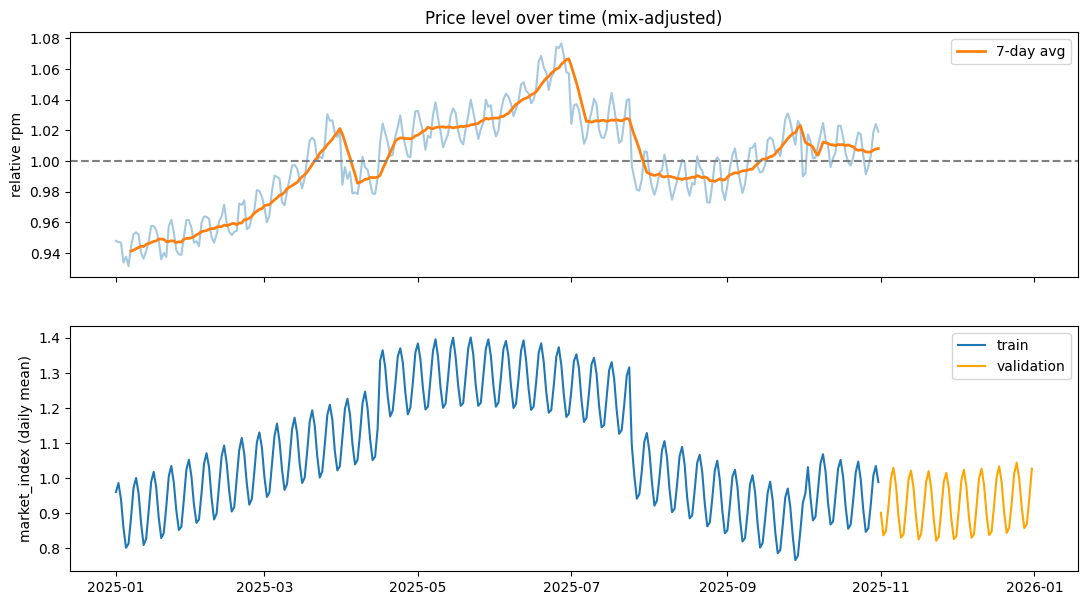

In [44]:
daily = c.groupby("date").agg(rel_rpm=("rel_rpm", "mean"), mi=("market_index", "mean"))
val_mi = val.groupby("date")["market_index"].mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(daily.index, daily["rel_rpm"], alpha=0.4)
axes[0].plot(daily.index, daily["rel_rpm"].rolling(7).mean(), linewidth=2, label="7-day avg")
axes[0].axhline(1, color="gray", linestyle="--")
axes[0].set_ylabel("relative rpm")
axes[0].legend()
axes[0].set_title("Price level over time (mix-adjusted)")

axes[1].plot(daily.index, daily["mi"], label="train")
axes[1].plot(val_mi.index, val_mi.values, color="orange", label="validation")
axes[1].set_ylabel("market_index (daily mean)")
axes[1].legend()
plt.show()

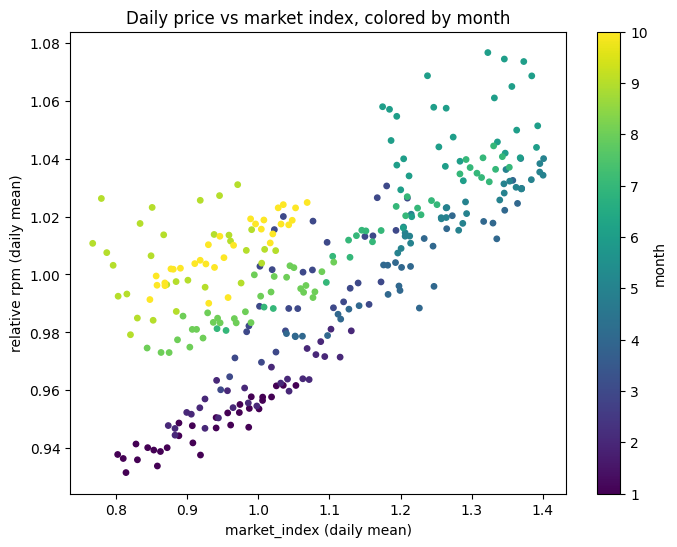

In [45]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(daily["mi"], daily["rel_rpm"], c=daily.index.month, cmap="viridis", s=15)
plt.colorbar(sc, label="month")
plt.xlabel("market_index (daily mean)")
plt.ylabel("relative rpm (daily mean)")
plt.title("Daily price vs market index, colored by month")
plt.show()

In [46]:
c.groupby(c["date"].dt.day_name())["rel_rpm"].mean().round(4).sort_values()

date
Sunday       0.9897
Monday       0.9925
Saturday     0.9964
Tuesday      0.9990
Friday       1.0066
Wednesday    1.0086
Thursday     1.0108
Name: rel_rpm, dtype: float64

In [47]:
from sklearn.linear_model import LinearRegression

daily["log_rel"] = np.log(daily["rel_rpm"])
daily["t"] = (daily.index - daily.index[0]).days

for cols in [["mi"], ["t"], ["mi", "t"]]:
    lr = LinearRegression().fit(daily[cols], daily["log_rel"])
    print(f"{str(cols):15s} R2 = {lr.score(daily[cols], daily['log_rel']):.3f}  coef = {lr.coef_.round(5)}")

lr = LinearRegression().fit(daily[["mi", "t"]], daily["log_rel"])
daily["resid"] = daily["log_rel"] - lr.predict(daily[["mi", "t"]])

['mi']          R2 = 0.487  coef = [0.13086]
['t']           R2 = 0.268  coef = [0.00018]
['mi', 't']     R2 = 0.845  coef = [0.14319 0.00021]


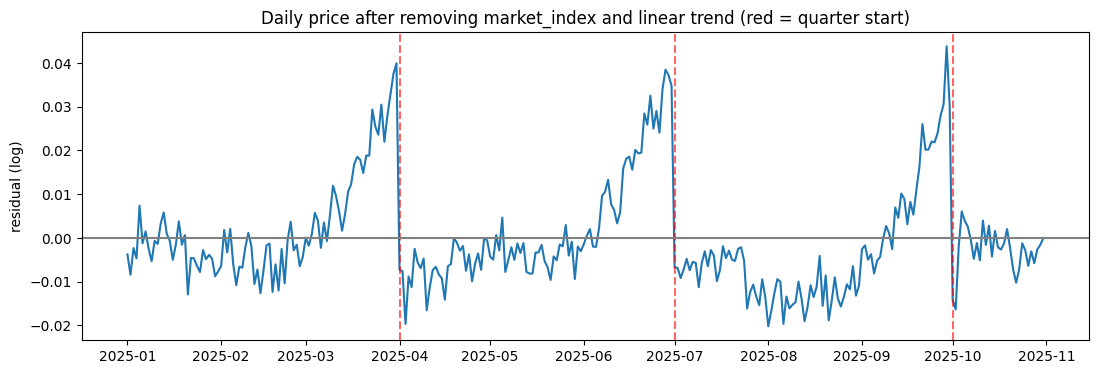

In [48]:
plt.figure(figsize=(13, 4))
plt.plot(daily.index, daily["resid"])
for q in ["2025-04-01", "2025-07-01", "2025-10-01"]:
    plt.axvline(pd.Timestamp(q), color="red", linestyle="--", alpha=0.6)
plt.axhline(0, color="gray")
plt.title("Daily price after removing market_index and linear trend (red = quarter start)")
plt.ylabel("residual (log)")
plt.show()

In [49]:
daily["month"] = daily.index.month
daily["quarter_end"] = daily["month"].isin([3, 6, 9])
daily["dom_bin"] = pd.cut(daily.index.day, [0, 7, 14, 21, 25, 28, 31])
daily.groupby(["month", "dom_bin"], observed=True)["resid"].mean().unstack().round(3)

dom_bin,"(0, 7]","(7, 14]","(14, 21]","(21, 25]","(25, 28]","(28, 31]"
month,,,,,,
1,-0.002,0.000,-0.002,-0.006,-0.004,-0.007
2,-0.004,-0.006,-0.006,-0.002,-0.004,NaN
3,0.001,0.006,0.016,0.024,0.027,0.037
4,-0.009,-0.009,-0.006,-0.006,-0.006,-0.000
5,-0.003,-0.004,-0.005,-0.003,-0.001,-0.005
6,0.001,0.009,0.020,0.028,0.032,0.036
7,-0.007,-0.006,-0.005,-0.006,-0.012,-0.013
8,-0.015,-0.015,-0.012,-0.013,-0.012,-0.010
9,-0.004,0.003,0.011,0.021,0.027,0.037


### Observations: time
- Mix-adjusted price level is not stationary: it rises from ≈0.94 (Jan) to ≈1.07 (late Jun), drops in Jul–Aug, and rises again in Sep–Oct.
- market_index has two components: a strong weekly cycle and multi-week level shifts (jump in mid-April, drop in late July).
- Price is highest on Thursday (1.011) and lowest on Sunday (0.990), mirroring the weekly cycle of market_index -> the day-of-week effect flows through market_index rather than being a separate driver.
- At the same market_index, later months are consistently more expensive (e.g. at mi ≈ 0.9: January ≈0.945 vs Sep–Oct ≈1.00) -> market_index alone does not explain price; there is an additional upward drift over time.
- Daily log price regressed on market_index alone: R2 = 0.49; on time alone: 0.27; on both: 0.845 (≈ +0.143 per unit of mi, ≈ +0.021%/day trend, ≈ +6.5% over the period).
- Key risk: validation market_index (≈0.82–1.04) is similar to January's. A tree model cannot extrapolate a time trend, so it would map Nov–Dec to January price levels and under-predict.
- After removing market_index and trend, the residual shows a clear quarter-end pattern: in March, June and September price ramps steadily from ≈0 to ≈+3.7% by the last days of the month, then resets on the first day of the next quarter. Other months are flat.
- December is a quarter-end month -> the December prediction should show this ramp.
- Assumptions to document: (1) the quarter-end ramp repeats in December (observed 3/3 times); (2) the linear trend continues for two more months (weakest assumption, cannot be verified). No holiday effects were visible around Jul 4 or Labor Day, so no holiday adjustment is made for Christmas / New Year.

## 6. quote_signal

In [50]:
c = train[~train["is_outlier"]].copy()
print("corr(quote_signal, rpm):", round(c["quote_signal"].corr(c["rpm"]), 3))
c["quote_signal"].describe().round(3)

corr(quote_signal, rpm): 0.102


count    47323.000
mean         2.063
std          0.291
min          0.692
25%          1.891
50%          2.056
75%          2.222
max          3.610
Name: quote_signal, dtype: float64

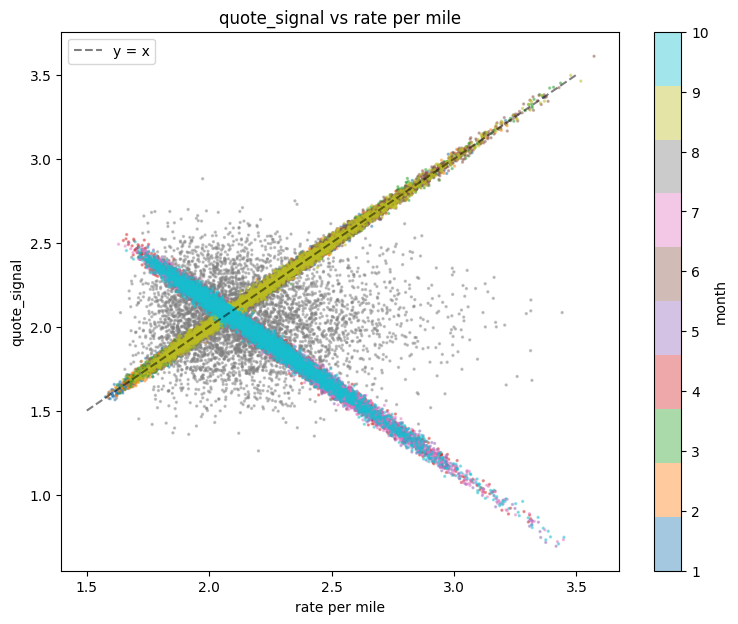

In [51]:
plt.figure(figsize=(9, 7))
sc = plt.scatter(c["rpm"], c["quote_signal"], c=c["date"].dt.month, cmap="tab10", s=2, alpha=0.4)
plt.colorbar(sc, label="month")
plt.plot([1.5, 3.5], [1.5, 3.5], "k--", alpha=0.5, label="y = x")
plt.xlabel("rate per mile")
plt.ylabel("quote_signal")
plt.legend()
plt.title("quote_signal vs rate per mile")
plt.show()

In [52]:
c.groupby(c["date"].dt.month).apply(
    lambda g: round(g["quote_signal"].corr(g["rpm"]), 3)
).rename("corr_with_rpm")

date
1     0.996
2     0.996
3     0.997
4    -0.993
5    -0.994
6     0.997
7    -0.994
8    -0.020
9     0.997
10   -0.994
Name: corr_with_rpm, dtype: float64

In [53]:
bins = [0, 150, 300, 500, 700, 1000, 1500, 2000, 2500, 3500]
ref = c.assign(dist_bin=pd.cut(c["distance"], bins)) \
       .groupby(["equipment", "dist_bin"], observed=True)["rpm"].median().rename("expected_rpm")

def corr_by_month(df):
    df = df.assign(dist_bin=pd.cut(df["distance"], bins)).join(ref, on=["equipment", "dist_bin"])
    return df.groupby(df["date"].dt.month).apply(
        lambda g: round(g["quote_signal"].corr(g["expected_rpm"]), 3))

print("train:", corr_by_month(c).to_dict())
print("val:  ", corr_by_month(val).to_dict())

train: {1: 0.925, 2: 0.924, 3: 0.917, 4: -0.915, 5: -0.921, 6: 0.927, 7: -0.915, 8: -0.016, 9: 0.928, 10: -0.921}
val:   {11: -0.001, 12: -0.018}


### Observations: quote_signal
- Overall correlation with rate per mile is only 0.10, which looks like a weak feature. This number is misleading: it averages three completely different regimes.
- Jan, Feb, Mar, Jun, Sep: quote_signal ≈ rate per mile (corr ≈ +0.997) -> effectively a leaked copy of the target.
- Apr, May, Jul, Oct: the relationship is inverted (corr ≈ -0.994).
- Aug: no relationship at all (corr ≈ -0.02).
- In validation (Nov, Dec), quote_signal has ~zero correlation with expected price (-0.001, -0.018) -> it behaves like August and carries no information in the prediction period.
- A model trained on it would learn to lean heavily on it (it is near-perfect for half the year) and then produce noisy predictions in Nov–Dec.
- It also corrupts naive validation: a Sep–Oct holdout includes a "leaky" month, so adding quote_signal appears to improve the score while actually harming real performance. August is the only training month whose quote_signal behaviour matches validation.
- Decision: drop quote_signal entirely.

## 7. Train vs validation

In [54]:
cols = ["distance", "weight", "market_index"]
pd.concat({"train": train[cols].describe().T, "val": val[cols].describe().T}, axis=1) \
  .swaplevel(axis=1).sort_index(axis=1)[["mean", "min", "50%", "max"]].round(3)

mean                   min                   50%  \
                  train        val      train        val      train   
distance       1135.857   1141.773     70.000     70.000    953.300   
weight        31028.844  30506.636 -47500.000 -47500.000  31436.500   
market_index      1.083      0.927      0.676      0.724      1.056   

                               max             
                    val      train        val  
distance        953.600   3439.800   3325.700  
weight        31193.000  47500.000  47500.000  
market_index      0.923      1.468      1.099

In [55]:
pd.DataFrame({
    "train": train["equipment"].value_counts(normalize=True),
    "val": val["equipment"].value_counts(normalize=True),
}).round(3)

,train,val
equipment,,
Dry Van,0.567,0.565
Reefer,0.251,0.254
Flatbed,0.182,0.181


In [56]:
def quality(df):
    return pd.Series({
        "negative weight": (df["weight"] < 0).sum(),
        "weight at 47,500 cap": (df["weight"].abs() == 47500).sum(),
        "weight at 5,000 floor": (df["weight"].abs() == 5000).sum(),
        "distance at 70 floor": (df["distance"] == 70).sum(),
        "lon at -69.5 clip": ((df["pickup_lon"] == -69.5) | (df["delivery_lon"] == -69.5)).sum(),
        "missing weight": df["weight"].isna().sum(),
        "missing market_index": df["market_index"].isna().sum(),
    })

pd.DataFrame({"train": quality(train), "val": quality(val)})

,train,val
negative weight,292,145
"weight at 47,500 cap",1204,301
"weight at 5,000 floor",32,7
distance at 70 floor,48,21
lon at -69.5 clip,2052,479
missing weight,300,165
missing market_index,374,249


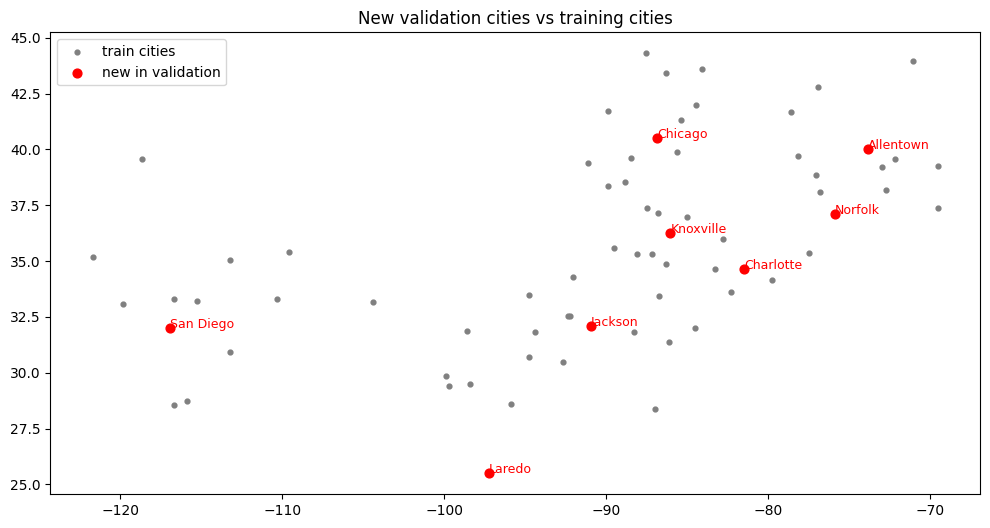

     city      lat        lon
   Laredo 25.50000  -97.22681
San Diego 32.00929 -116.89598
  Jackson 32.07771  -90.92587
Charlotte 34.65272  -81.47202
Knoxville 36.25725  -86.02539
  Norfolk 37.12278  -75.87106
Allentown 40.01684  -73.80889
  Chicago 40.51200  -86.86737

Train lat range: 28.35765 -> 44.30296


In [57]:
val_cities = pd.concat([
    val[["pickup", "pickup_lat", "pickup_lon"]].set_axis(["city", "lat", "lon"], axis=1),
    val[["delivery", "delivery_lat", "delivery_lon"]].set_axis(["city", "lat", "lon"], axis=1),
]).drop_duplicates()
new = val_cities[val_cities["city"].isin(new_cities)]

plt.figure(figsize=(12, 6))
plt.scatter(cities["lon"], cities["lat"], s=12, color="gray", label="train cities")
plt.scatter(new["lon"], new["lat"], s=40, color="red", label="new in validation")
for _, r in new.iterrows():
    plt.annotate(r["city"], (r["lon"], r["lat"]), fontsize=9, color="red")
plt.legend()
plt.title("New validation cities vs training cities")
plt.show()

print(new.sort_values("lat").to_string(index=False))
print("\nTrain lat range:", cities["lat"].min(), "->", cities["lat"].max())

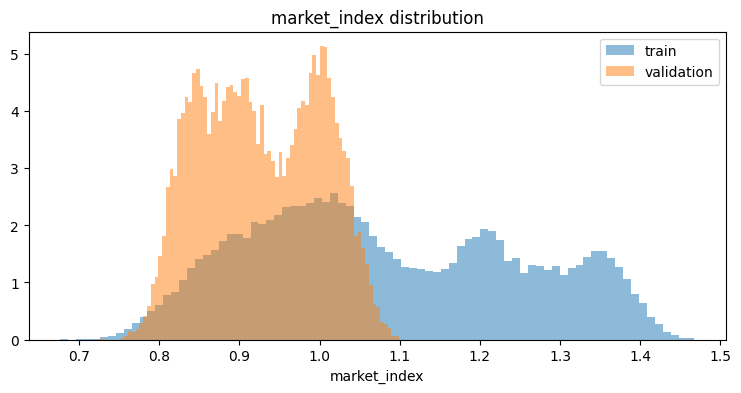

In [58]:
plt.figure(figsize=(9, 4))
plt.hist(train["market_index"].dropna(), bins=80, alpha=0.5, density=True, label="train")
plt.hist(val["market_index"].dropna(), bins=80, alpha=0.5, density=True, label="validation")
plt.xlabel("market_index")
plt.legend()
plt.title("market_index distribution")
plt.show()

### Observations: train vs validation
- Distance, weight and equipment mix are almost identical between train and validation -> the type of loads did not change, only time and market conditions did.
- All data-quality issues found in train also appear in validation, some at higher rates (negative weights: 0.61% train vs 1.21% val). Cleaning must be a single function applied identically to train, validation and the December inputs.
- Validation market_index (0.724–1.099) lies inside the training range (0.676–1.468) but in its lower part (mean 0.927 vs 1.083), resembling January and Aug–Oct. The model must distinguish "low index in November" from "low index in January" -> the time trend is essential.
- 7 of the 8 new cities fall inside the training geographic area. Laredo sits at exactly lat = 25.5, below the training minimum (28.36) -> latitudes are also clipped at a southern boundary, and Laredo is a mild extrapolation for coordinate-based features.

## 8. Summary

### Dataset
- Train: 48,000 labelled loads, Jan–Oct 2025. Validation: 12,000 loads, Nov–Dec 2025 -> this is a forecasting problem.
- Load mix (distance, weight, equipment) is stable between train and validation; what changes is time and market conditions.

### Data-quality issues and decisions

| Issue | Evidence | Decision |
|---|---|---|
| Corrupted labels (677 rows, 1.4%) | Rate per mile forms separate clusters at ≈0.3x and ≈3.5x the normal level, with empty gaps; evenly spread across months and equipment | Drop from training (global rpm threshold < 1.4 or > 3.8) |
| Negative weights (292 train, 145 val) | Mirror the positive distribution, including -47,500 | Take abs() |
| Weight capped at 47,500 / floored at 5,000 | Spikes at exact values | Keep as-is (unrecoverable) |
| Missing weight (0.6% train, 1.4% val) | Random, no price signal | Fill with training median |
| Missing market_index (0.8% train, 2.1% val) | Random; ~98% of variance is day-level | Fill with same-date mean |
| Distance floored at 70 | 48 rows at exactly 70, prices consistent with floored value | Keep as-is |
| Perturbed / clipped coordinates | Not real geography; lon clipped at -69.5, lat at 25.5 | Use only as approximate location, mainly for unseen cities |
| quote_signal | Corr ≈ +1 in 5 months, ≈ -1 in 4 months, ≈ 0 in Aug and in Nov–Dec | Drop entirely |

### What drives price
- Distance: dominant driver; rate per mile declines with distance (fixed per-load costs).
- Equipment: multiplicative and constant across distances (Flatbed ≈1.08x, Reefer ≈1.13x Dry Van) -> model log(rate).
- Weight: modest positive effect (≈+9% lightest -> heaviest).
- market_index: strong positive effect (≈+14% per unit), includes a weekly cycle that explains the day-of-week pattern.
- Time trend: ≈+0.021%/day independent of market_index.
- Quarter-end ramp: in Mar, Jun, Sep price climbs steadily to ≈+3.7% by month end, then resets.
- market_index + trend explain 84.5% of daily price variation.

### Implications for modelling
1. Target: log(posted_rate).
2. The model must extrapolate the time trend and the quarter-end ramp into Nov–Dec. Tree models cannot extrapolate, so these components need an explicit (e.g. linear) treatment.
3. 12% of validation rows involve cities never seen in training -> the model must generalise via distance and coordinates, not only city identity.
4. Validation must be time-based (train on earlier months, evaluate on later months). It should also include a quarter-end month and an unseen-city check to mirror the real prediction setting.
5. December chart inputs lack market_index and coordinates -> fill coordinates from the city lookup and market_index from the validation same-date mean.

### Key assumptions
- The quarter-end ramp repeats in December (observed 3/3 times).
- The linear trend continues for two more months (weakest assumption).
- No holiday adjustment for Christmas / New Year, since no holiday effects were visible in the training data.